In [84]:
import pandas as pd
import glob
import numpy as np
import statsmodels.api as sm

### 1.读入数据

### 2.构造尾部状态变量：如果某个币当天收益率低于自身历史5%分位数，则记为1，表示该币进入左尾风险状态；否则记为0。

In [85]:
#读入数据并检查
returns_raw = pd.read_csv("processed_data/crypto_returns.csv")
returns_raw["date"] = pd.to_datetime(returns_raw["date"])
returns = returns_raw.set_index("date").sort_index()

print(returns.head())
print(returns.tail())
print(returns.shape)
print(returns.isna().sum())

                                ada       bch       btc       cro      doge  \
date                                                                          
2019-01-03 00:00:00+00:00  0.064768  0.036779  0.020325 -0.003597 -0.004526   
2019-01-04 00:00:00+00:00 -0.062467 -0.057206 -0.025011  0.002068 -0.022516   
2019-01-05 00:00:00+00:00  0.029247  0.003813  0.010206  0.007592 -0.018287   
2019-01-06 00:00:00+00:00  0.021733 -0.020272 -0.007355 -0.140205  0.003784   
2019-01-07 00:00:00+00:00  0.091710  0.042533  0.058013 -0.075321  0.003640   

                                eth      link       ltc       trx      usdc  \
date                                                                          
2019-01-03 00:00:00+00:00  0.101223  0.078310  0.048631  0.028296 -0.001603   
2019-01-04 00:00:00+00:00 -0.040927  0.077437 -0.048059 -0.004515  0.003250   
2019-01-05 00:00:00+00:00  0.042209  0.176500  0.016017  0.073593 -0.000177   
2019-01-06 00:00:00+00:00  0.003882 -0.081817  0.07

In [86]:
#构造尾部状态变量：如果某个币当天收益率低于自身历史5%分位数，则记为1，表示该币进入左尾风险状态；否则记为0。
# 计算每个币自身收益率的5%分位数
tail_threshold = returns.quantile(0.05)

# 构造尾部状态变量：1=该币进入尾部风险状态，0=未进入
tail_state = (returns.lt(tail_threshold)).astype(int)

# 保存结果
tail_state.to_csv("processed_data/crypto_tail_state_5pct.csv", encoding="utf-8-sig")

print("各币5%分位数阈值：")
print(tail_threshold)

print("\n尾部状态变量前5行：")
print(tail_state.head())

print("\n各币进入尾部状态的比例：")
print(tail_state.mean())

各币5%分位数阈值：
ada    -0.073823
bch    -0.070145
btc    -0.048309
cro    -0.076265
doge   -0.073977
eth    -0.064896
link   -0.082066
ltc    -0.071016
trx    -0.061462
usdc   -0.003205
usdt   -0.002841
xlm    -0.067218
xmr    -0.065248
xrp    -0.067960
zec    -0.085222
Name: 0.05, dtype: float64

尾部状态变量前5行：
                           ada  bch  btc  cro  doge  eth  link  ltc  trx  \
date                                                                       
2019-01-03 00:00:00+00:00    0    0    0    0     0    0     0    0    0   
2019-01-04 00:00:00+00:00    0    0    0    0     0    0     0    0    0   
2019-01-05 00:00:00+00:00    0    0    0    0     0    0     0    0    0   
2019-01-06 00:00:00+00:00    0    0    0    1     0    0     0    0    0   
2019-01-07 00:00:00+00:00    0    0    0    0     0    0     0    0    0   

                           usdc  usdt  xlm  xmr  xrp  zec  
date                                                       
2019-01-03 00:00:00+00:00     0     0    0

后续TE网络不再直接研究收益率涨跌幅，而是研究“某个币进入尾部风险状态”是否会提高“另一个币下一期进入尾部风险状态”的信息解释力。

### 3.构造市场尾部状态，用于解释样本期（说明哪些日期属于全市场极端下跌日，后面可以对照 Covid、Luna、FTX 等事件。）

In [89]:
market_return = returns.mean(axis=1)
market_tail_threshold = market_return.quantile(0.05)
market_tail_state = (market_return < market_tail_threshold).astype(int)

market_tail_df = pd.DataFrame({
    "market_return": market_return,
    "market_tail_state": market_tail_state
})

market_tail_df.to_csv("processed_data/market_tail_state_5pct.csv", encoding="utf-8-sig")

print("市场组合收益率5%分位数：", market_tail_threshold)
print("市场尾部风险日数量：", market_tail_state.sum())
print("市场尾部风险日比例：", market_tail_state.mean())

市场组合收益率5%分位数： -0.051942204571439436
市场尾部风险日数量： 128
市场尾部风险日比例： 0.050117462803445575


### 4.写 Transfer Entropy 函数——二元尾部状态TE

In [90]:
from collections import Counter

def transfer_entropy_binary(x, y, eps=1e-12):
    """
    计算一阶二元 Transfer Entropy: X_t -> Y_{t+1} | Y_t

    x: 资产i的尾部状态序列，0/1
    y: 资产j的尾部状态序列，0/1

    返回值：
    TE_{i -> j}
    """
    x = np.asarray(x).astype(int)
    y = np.asarray(y).astype(int)

    # 对齐 x_t, y_t, y_{t+1}
    x_t = x[:-1]
    y_t = y[:-1]
    y_next = y[1:]

    n = len(y_next)
    if n == 0:
        return np.nan

    triples = list(zip(y_next, y_t, x_t))
    pairs_yx = list(zip(y_t, x_t))
    pairs_yy = list(zip(y_next, y_t))
    singles_y = list(y_t)

    c_triple = Counter(triples)
    c_yx = Counter(pairs_yx)
    c_yy = Counter(pairs_yy)
    c_y = Counter(singles_y)

    te = 0.0

    for (yn, yt, xt), count in c_triple.items():
        p_yn_yt_xt = count / n

        p1 = count / c_yx[(yt, xt)]          # P(y_{t+1}|y_t,x_t)
        p2 = c_yy[(yn, yt)] / c_y[yt]       # P(y_{t+1}|y_t)

        te += p_yn_yt_xt * np.log((p1 + eps) / (p2 + eps))

    return te

### 5.计算TE矩阵

In [91]:
coins = list(tail_state.columns)
te_matrix = pd.DataFrame(
    np.zeros((len(coins), len(coins))),
    index=coins,
    columns=coins
)

for i in coins:
    for j in coins:
        if i != j:
            te_matrix.loc[i, j] = transfer_entropy_binary(
                tail_state[i].values,
                tail_state[j].values
            )

te_matrix.to_csv("processed_data/te_matrix_full_sample.csv", encoding="utf-8-sig")

print(te_matrix.round(6))

           ada       bch       btc       cro      doge       eth      link  \
ada   0.000000  0.000896  0.000615  0.002316  0.000662  0.000316  0.000470   
bch   0.000633  0.000000  0.001287  0.001267  0.000619  0.000106  0.000218   
btc   0.000331  0.000470  0.000000  0.000635  0.000196  0.000807  0.000075   
cro   0.000438  0.001046  0.000344  0.000000  0.000151  0.000203  0.000726   
doge  0.000158  0.000301  0.000070  0.000150  0.000000  0.000212  0.000388   
eth   0.000510  0.000838  0.000289  0.001638  0.000369  0.000000  0.000283   
link  0.000421  0.000876  0.000448  0.002486  0.000641  0.000635  0.000000   
ltc   0.001038  0.003587  0.001249  0.001138  0.001179  0.001289  0.000883   
trx   0.001340  0.000507  0.000078  0.003623  0.001289  0.001619  0.001213   
usdc  0.000829  0.000867  0.002386  0.000199  0.000491  0.001205  0.000794   
usdt  0.000282  0.001285  0.000997  0.000926  0.000792  0.000513  0.000414   
xlm   0.000543  0.000549  0.000431  0.000810  0.000375  0.000135

### 6.找出最强风险传染边

In [92]:
edge_list = []

for i in coins:
    for j in coins:
        if i != j:
            edge_list.append({
                "sender": i,
                "receiver": j,
                "TE": te_matrix.loc[i, j]
            })

edge_df = pd.DataFrame(edge_list).sort_values("TE", ascending=False)

edge_df.to_csv("processed_data/top_te_edges_full_sample.csv", index=False, encoding="utf-8-sig")

print(edge_df.head(20))

    sender receiver        TE
8      ada     usdc  0.003891
91    link      trx  0.003631
115    trx      cro  0.003623
99     ltc      bch  0.003587
36     btc     usdc  0.003572
122    trx      xlm  0.003551
120    trx     usdc  0.003507
178    xmr     usdt  0.003425
78     eth     usdc  0.003314
108    ltc      xlm  0.003191
148   usdt      trx  0.002892
51     cro     usdt  0.002787
24     bch      xlm  0.002630
166    xlm      xrp  0.002592
191    xrp     usdc  0.002501
87    link      cro  0.002486
128   usdc      btc  0.002386
2      ada      cro  0.002316
22     bch     usdc  0.002311
92    link     usdc  0.002241


表4-2展示了全样本尾部风险传染网络中TE值最高的主要方向性边。从结果看，较强的尾部风险信息传递关系并未完全局限于BTC和ETH等核心定价资产，而是同时分布在公链及基础设施资产、支付结算类资产与稳定币之间。其中，ADA→USDC、BTC→USDC、ETH→USDC、TRX→USDC和LINK→USDC等边表明，在尾部风险状态下，风险资产的极端波动可能对稳定币下一期的负向偏离产生信息增量。与此同时，LINK→TRX、TRX→CRO、LTC→BCH和LTC→XLM等边说明，部分功能相近或交易活跃资产之间也存在较强的尾部状态传递关系。整体来看，全样本网络呈现跨类别传染特征，说明加密市场尾部风险并非仅沿核心资产扩散，而是通过稳定币、基础设施资产和支付结算类资产形成多路径传播结构。


### 7.筛选有效边——先保留 TE值最高的前20%边，大约保留42条边。只保留全样本中方向性信息传递最强的一批边，用于展示尾部风险传染网络的主要骨架。

In [93]:
positive_values = te_matrix.values.flatten()
positive_values = positive_values[positive_values > 0]
#保留前20%强边
threshold = np.quantile(positive_values, 0.80)

adj_matrix = te_matrix.where(te_matrix >= threshold, 0)
adj_matrix.to_csv("processed_data/te_adj_top20_full_sample.csv", encoding="utf-8-sig")

print("前20%强边阈值：", threshold)
print("保留边数量：", (adj_matrix.values > 0).sum())

前20%强边阈值： 0.0013407072763833813
保留边数量： 42


为避免弱连接干扰网络结构识别，本文基于全样本TE矩阵对风险传染边进行筛选，保留TE值位于前20%的方向性边作为主要网络骨架。该处理有助于突出尾部状态下较强的信息传递关系，并提高网络图的可解释性。

### 8.构建networkx有向网络

In [94]:
import networkx as nx
import matplotlib.pyplot as plt

In [95]:
asset_group = {
    "btc": "核心定价资产",
    "eth": "核心定价资产",

    "bch": "支付结算及隐私资产",
    "ltc": "支付结算及隐私资产",
    "xrp": "支付结算及隐私资产",
    "xlm": "支付结算及隐私资产",
    "xmr": "支付结算及隐私资产",
    "zec": "支付结算及隐私资产",

    "ada": "公链及基础设施资产",
    "trx": "公链及基础设施资产",
    "link": "公链及基础设施资产",

    "usdt": "稳定币",
    "usdc": "稳定币",

    "cro": "平台生态及情绪交易资产",
    "doge": "平台生态及情绪交易资产"
}

In [96]:
print(coins)

for c in coins:
    if c not in asset_group:
        print("未分类币种：", c)

['ada', 'bch', 'btc', 'cro', 'doge', 'eth', 'link', 'ltc', 'trx', 'usdc', 'usdt', 'xlm', 'xmr', 'xrp', 'zec']


In [97]:
G = nx.DiGraph()

for coin in coins:
    G.add_node(coin, group=asset_group.get(coin, "其他"))

for i in coins:
    for j in coins:
        weight = adj_matrix.loc[i, j]
        if i != j and weight > 0:
            G.add_edge(i, j, weight=weight)

print("节点数：", G.number_of_nodes())
print("边数：", G.number_of_edges())
print("网络密度：", nx.density(G))

节点数： 15
边数： 42
网络密度： 0.2


### 9.生成全样本网络统计表

In [98]:
edge_weights = [G[u][v]["weight"] for u, v in G.edges()]

network_summary = pd.DataFrame({
    "指标": ["节点数", "边数", "网络密度", "平均边权", "最大边权", "最小边权"],
    "数值": [
        G.number_of_nodes(),
        G.number_of_edges(),
        nx.density(G),
        np.mean(edge_weights) if len(edge_weights) > 0 else 0,
        np.max(edge_weights) if len(edge_weights) > 0 else 0,
        np.min(edge_weights) if len(edge_weights) > 0 else 0
    ]
})

network_summary.to_csv(
    "processed_data/table_4_1_network_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print(network_summary)

     指标         数值
0   节点数  15.000000
1    边数  42.000000
2  网络密度   0.200000
3  平均边权   0.002338
4  最大边权   0.003891
5  最小边权   0.001342


筛选后的全样本网络包含15个节点和X条有向边，网络密度为0.2，说明在主要风险传染边中，约20%的潜在方向性关系被保留。

In [99]:
out_strength = dict(G.out_degree(weight="weight"))#出度强度：该币向其他币传递风险信息的总强度
in_strength = dict(G.in_degree(weight="weight"))#入度强度：该币接收其他币风险信息的总强度

node_stats = pd.DataFrame({
    "coin": coins,
    "group": [asset_group.get(c, "其他") for c in coins],
    "out_strength": [out_strength.get(c, 0) for c in coins],
    "in_strength": [in_strength.get(c, 0) for c in coins]
})

node_stats["net_out_strength"] = node_stats["out_strength"] - node_stats["in_strength"]
node_stats.to_csv(
    "processed_data/node_stats_full_sample.csv",
    index=False,
    encoding="utf-8-sig"
)

print("按出度强度排序：")
print(node_stats.sort_values("out_strength", ascending=False))

print("\n按入度强度排序：")
print(node_stats.sort_values("in_strength", ascending=False))

print("\n按净输出强度排序：")
print(node_stats.sort_values("net_out_strength", ascending=False))

按出度强度排序：
    coin        group  out_strength  in_strength  net_out_strength
8    trx    公链及基础设施资产      0.017730     0.014007          0.003723
7    ltc    支付结算及隐私资产      0.013265     0.003761          0.009504
0    ada    公链及基础设施资产      0.012104     0.000000          0.012104
6   link    公链及基础设施资产      0.008358     0.000000          0.008358
10  usdt          稳定币      0.006920     0.011726         -0.004806
11   xlm    支付结算及隐私资产      0.005858     0.013059         -0.007201
9   usdc          稳定币      0.005636     0.029001         -0.023364
13   xrp    支付结算及隐私资产      0.005563     0.007521         -0.001957
12   xmr    支付结算及隐私资产      0.005169     0.001469          0.003700
5    eth       核心定价资产      0.004952     0.001619          0.003332
1    bch    支付结算及隐私资产      0.004942     0.003587          0.001354
3    cro  平台生态及情绪交易资产      0.004129     0.010062         -0.005933
2    btc       核心定价资产      0.003572     0.002386          0.001187
4   doge  平台生态及情绪交易资产      0.000000     0.000000     

【待解释】

### 11.生成 Top 10 风险传染边表

In [100]:
top10_edges = edge_df.head(10).copy()#论文只放前10条

top10_edges.to_csv(
    "processed_data/table_4_2_top10_te_edges.csv",
    index=False,
    encoding="utf-8-sig"
)

print(top10_edges)
#sender：风险输出方 receiver：风险输入方

    sender receiver        TE
8      ada     usdc  0.003891
91    link      trx  0.003631
115    trx      cro  0.003623
99     ltc      bch  0.003587
36     btc     usdc  0.003572
122    trx      xlm  0.003551
120    trx     usdc  0.003507
178    xmr     usdt  0.003425
78     eth     usdc  0.003314
108    ltc      xlm  0.003191


表4-2 全样本尾部风险传染网络的主要方向性边

### 12.全样本网络图（最重要）【可以改用gephi画图？】

In [101]:
group_color = {
    "核心定价资产": "#d62728",
    "支付结算及隐私资产": "#1f77b4",
    "公链及基础设施资产": "#2ca02c",
    "稳定币": "#ff7f0e",
    "平台生态及情绪交易资产": "#9467bd",
    "其他": "#7f7f7f"
}

node_colors = [
    group_color.get(G.nodes[node]["group"], "#7f7f7f")
    for node in G.nodes()
]

In [102]:
#节点大小按照出度强度设置
node_sizes = []
for node in G.nodes():
    node_sizes.append(800 + 8000 * out_strength.get(node, 0))

In [103]:
#边宽按TE权重设置。
edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
max_w = max(edge_weights) if len(edge_weights) > 0 else 1
edge_widths = [1 + 4 * w / max_w for w in edge_weights]

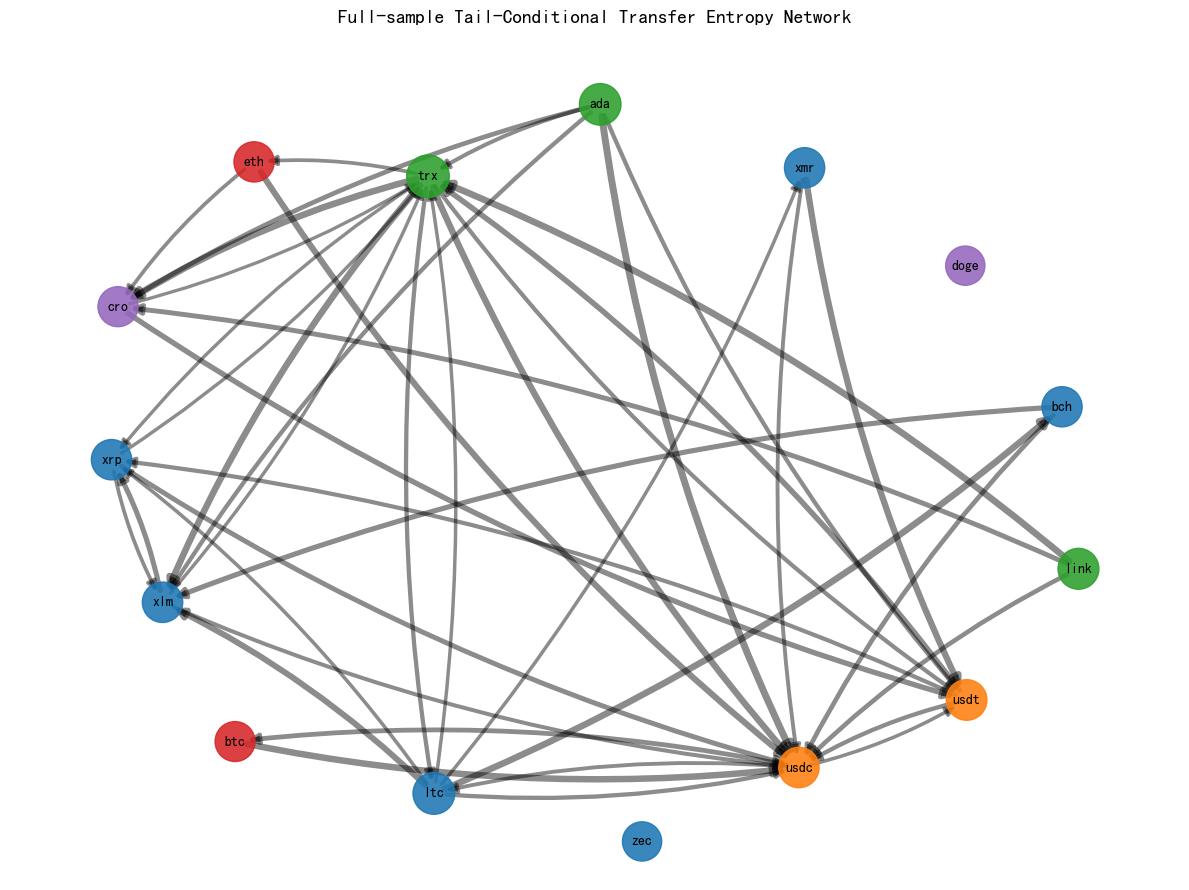

In [104]:
plt.figure(figsize=(12, 9))

pos = nx.spring_layout(G, seed=42, k=0.9)#自动布局

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    alpha=0.88
)

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    alpha=0.45,
    arrows=True,
    arrowsize=14,
    connectionstyle="arc3,rad=0.08"
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_weight="bold"
)

plt.title("Full-sample Tail-Conditional Transfer Entropy Network", fontsize=14)
plt.axis("off")
plt.tight_layout()V

plt.savefig(
    "processed_data/figure_4_1_full_sample_te_network.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 13.画 TE 矩阵热力图：展示所有资产之间TE强弱，作为辅助图。


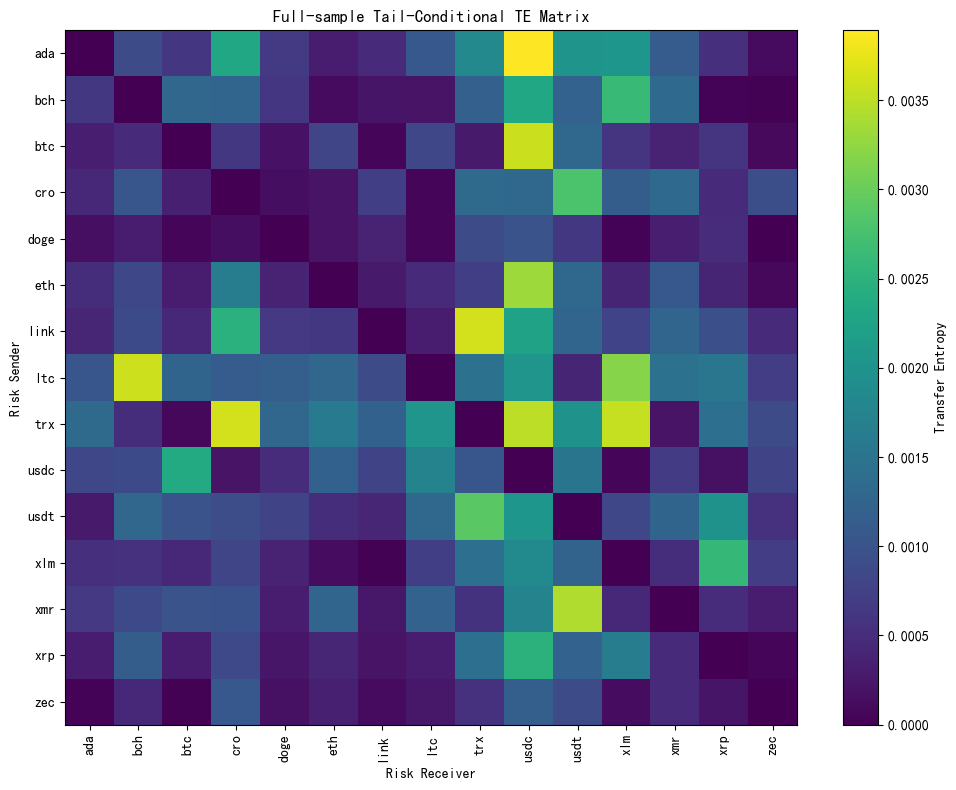

In [105]:
plt.figure(figsize=(10, 8))

plt.imshow(te_matrix.values, aspect="auto")
plt.colorbar(label="Transfer Entropy")

plt.xticks(range(len(coins)), coins, rotation=90)
plt.yticks(range(len(coins)), coins)

plt.xlabel("Risk Receiver")
plt.ylabel("Risk Sender")
plt.title("Full-sample Tail-Conditional TE Matrix")

plt.tight_layout()

plt.savefig(
    "processed_data/figure_4_2_te_matrix_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 14.生成组间传染矩阵：组间矩阵可以看哪一类资产向哪一类资产传递风险更强。

In [106]:
group_edges = []

for i in coins:
    for j in coins:
        if i != j:
            sender_group = asset_group.get(i, "其他")
            receiver_group = asset_group.get(j, "其他")
            group_edges.append({
                "sender_group": sender_group,
                "receiver_group": receiver_group,
                "TE": te_matrix.loc[i, j]
            })

group_edge_df = pd.DataFrame(group_edges)

group_te_matrix = group_edge_df.pivot_table(
    index="sender_group",
    columns="receiver_group",
    values="TE",
    aggfunc="mean"
)

group_te_matrix.to_csv(
    "processed_data/group_te_matrix_full_sample.csv",
    encoding="utf-8-sig"
)

print(group_te_matrix.round(6))

receiver_group  公链及基础设施资产  平台生态及情绪交易资产  支付结算及隐私资产    核心定价资产       稳定币
sender_group                                                         
公链及基础设施资产        0.001486     0.001836   0.001059  0.000619  0.002484
平台生态及情绪交易资产      0.000656     0.000150   0.000517  0.000207  0.001433
支付结算及隐私资产        0.000641     0.000752   0.000943  0.000653  0.001667
核心定价资产           0.000367     0.000710   0.000522  0.000548  0.002374
稳定币              0.001042     0.000602   0.000963  0.001275  0.001780


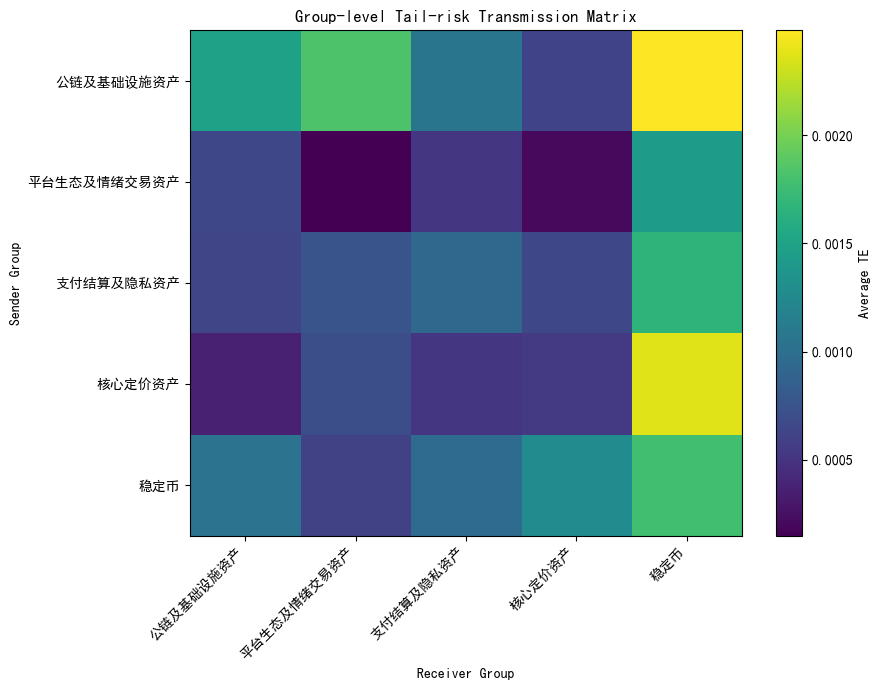

In [107]:
#热力图
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False
plt.figure(figsize=(9, 7))

plt.imshow(group_te_matrix.values, aspect="auto")
plt.colorbar(label="Average TE")

plt.xticks(
    range(len(group_te_matrix.columns)),
    group_te_matrix.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(group_te_matrix.index)),
    group_te_matrix.index
)

plt.xlabel("Receiver Group")
plt.ylabel("Sender Group")
plt.title("Group-level Tail-risk Transmission Matrix")

plt.tight_layout()

plt.savefig(
    "processed_data/figure_4_3_group_te_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 15.保存结果


In [36]:
print("已生成文件：")
print("1. processed_data/te_adj_top20_full_sample.csv")
print("2. processed_data/table_4_1_network_summary.csv")
print("3. processed_data/node_stats_full_sample.csv")
print("4. processed_data/table_4_2_top10_te_edges.csv")
print("5. processed_data/table_4_2_top10_te_edges_cn.csv")
print("6. processed_data/figure_4_1_full_sample_te_network.png")
print("7. processed_data/figure_4_2_te_matrix_heatmap.png")
print("8. processed_data/group_te_matrix_full_sample.csv")
print("9. processed_data/figure_4_3_group_te_matrix.png")

已生成文件：
1. processed_data/te_adj_top20_full_sample.csv
2. processed_data/table_4_1_network_summary.csv
3. processed_data/node_stats_full_sample.csv
4. processed_data/table_4_2_top10_te_edges.csv
5. processed_data/table_4_2_top10_te_edges_cn.csv
6. processed_data/figure_4_1_full_sample_te_network.png
7. processed_data/figure_4_2_te_matrix_heatmap.png
8. processed_data/group_te_matrix_full_sample.csv
9. processed_data/figure_4_3_group_te_matrix.png


### last：结果统计

In [37]:
print(network_summary)

     指标         数值
0   节点数  15.000000
1    边数  42.000000
2  网络密度   0.200000
3  平均边权   0.002338
4  最大边权   0.003891
5  最小边权   0.001342


In [38]:
print(top10_edges_cn)

     排名 风险输出方 风险接收方       TE值
8     1   ada  usdc  0.003891
91    2  link   trx  0.003631
115   3   trx   cro  0.003623
99    4   ltc   bch  0.003587
36    5   btc  usdc  0.003572
122   6   trx   xlm  0.003551
120   7   trx  usdc  0.003507
178   8   xmr  usdt  0.003425
78    9   eth  usdc  0.003314
108  10   ltc   xlm  0.003191


In [39]:
print(node_stats.sort_values("out_strength", ascending=False))
print(node_stats.sort_values("in_strength", ascending=False))

    coin        group  out_strength  in_strength  net_out_strength
8    trx    公链及基础设施资产      0.017730     0.014007          0.003723
7    ltc    支付结算及隐私资产      0.013265     0.003761          0.009504
0    ada    公链及基础设施资产      0.012104     0.000000          0.012104
6   link    公链及基础设施资产      0.008358     0.000000          0.008358
10  usdt          稳定币      0.006920     0.011726         -0.004806
11   xlm    支付结算及隐私资产      0.005858     0.013059         -0.007201
9   usdc          稳定币      0.005636     0.029001         -0.023364
13   xrp    支付结算及隐私资产      0.005563     0.007521         -0.001957
12   xmr    支付结算及隐私资产      0.005169     0.001469          0.003700
5    eth       核心定价资产      0.004952     0.001619          0.003332
1    bch    支付结算及隐私资产      0.004942     0.003587          0.001354
3    cro  平台生态及情绪交易资产      0.004129     0.010062         -0.005933
2    btc       核心定价资产      0.003572     0.002386          0.001187
4   doge  平台生态及情绪交易资产      0.000000     0.000000          0.00

In [40]:
print(group_te_matrix.round(6))

receiver_group  公链及基础设施资产  平台生态及情绪交易资产  支付结算及隐私资产    核心定价资产       稳定币
sender_group                                                         
公链及基础设施资产        0.001486     0.001836   0.001059  0.000619  0.002484
平台生态及情绪交易资产      0.000656     0.000150   0.000517  0.000207  0.001433
支付结算及隐私资产        0.000641     0.000752   0.000943  0.000653  0.001667
核心定价资产           0.000367     0.000710   0.000522  0.000548  0.002374
稳定币              0.001042     0.000602   0.000963  0.001275  0.001780


# 4.3 网络动态演化部分

In [41]:
#检查基础变量
print(tail_state.shape)
print(coins)
print(te_matrix.shape)

(2554, 15)
['ada', 'bch', 'btc', 'cro', 'doge', 'eth', 'link', 'ltc', 'trx', 'usdc', 'usdt', 'xlm', 'xmr', 'xrp', 'zec']
(15, 15)


第二步：设定滚动窗口参数和固定阈值

In [42]:
# 滚动窗口设置
window_size = 120
step_size = 30

# 使用全样本TE矩阵前20%强边阈值作为动态网络固定筛选阈值
positive_values = te_matrix.values.flatten()
positive_values = positive_values[positive_values > 0]

fixed_threshold = np.quantile(positive_values, 0.80)

print("固定TE阈值：", fixed_threshold)

固定TE阈值： 0.0013407072763833813


第三步 网络指标函数

In [43]:
from networkx.algorithms.community import greedy_modularity_communities, modularity

def weighted_entropy_from_edges(edge_weights, eps=1e-12):
    """
    计算加权网络熵。
    edge_weights: 保留边的权重列表
    """
    weights = np.array(edge_weights, dtype=float)
    weights = weights[weights > 0]

    if len(weights) <= 1:
        return 0.0

    p = weights / weights.sum()
    entropy = -np.sum(p * np.log(p + eps))

    # 标准化到0-1之间，便于不同窗口比较
    entropy_norm = entropy / np.log(len(weights))

    return entropy_norm


def directed_to_undirected_weighted(G):
    """
    将有向图转为无向加权图。
    若 i->j 和 j->i 同时存在，则权重相加。
    """
    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))

    for u, v, data in G.edges(data=True):
        w = data.get("weight", 1.0)
        if H.has_edge(u, v):
            H[u][v]["weight"] += w
        else:
            H.add_edge(u, v, weight=w)

    return H


def compute_network_metrics(G):
    """
    输入一个有向加权网络，输出主要动态网络指标。
    """
    n = G.number_of_nodes()
    m = G.number_of_edges()

    density = nx.density(G)

    edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
    avg_weight = np.mean(edge_weights) if len(edge_weights) > 0 else 0
    total_weight = np.sum(edge_weights) if len(edge_weights) > 0 else 0
    net_entropy = weighted_entropy_from_edges(edge_weights)

    # 最大弱连通分量比例
    if m > 0:
        largest_wcc = max(nx.weakly_connected_components(G), key=len)
        max_component_ratio = len(largest_wcc) / n
    else:
        max_component_ratio = 0

    # 模块度：转为无向图后计算
    if m > 0:
        H = directed_to_undirected_weighted(G)

        try:
            communities = list(greedy_modularity_communities(H, weight="weight"))
            mod = modularity(H, communities, weight="weight")
            n_communities = len(communities)
        except:
            mod = np.nan
            n_communities = np.nan
    else:
        mod = np.nan
        n_communities = 0

    return {
        "edge_num": m,
        "density": density,
        "avg_weight": avg_weight,
        "total_weight": total_weight,
        "network_entropy": net_entropy,
        "max_component_ratio": max_component_ratio,
        "modularity": mod,
        "n_communities": n_communities
    }

第四步：“窗口内计算TE矩阵”封装函数

In [44]:
def compute_te_matrix_for_window(tail_window, coins):
    """
    对某一个滚动窗口内的尾部状态变量计算TE矩阵。
    tail_window: 某一窗口内的0/1尾部状态数据
    """
    te_win = pd.DataFrame(
        np.zeros((len(coins), len(coins))),
        index=coins,
        columns=coins
    )

    for i in coins:
        for j in coins:
            if i != j:
                te_win.loc[i, j] = transfer_entropy_binary(
                    tail_window[i].values,
                    tail_window[j].values
                )

    return te_win

第五步 TE矩阵转网络 封装函数

In [45]:
def build_graph_from_te_matrix(te_win, threshold, coins, asset_group):
    """
    根据固定TE阈值筛边，并构建有向加权网络。
    """
    adj_win = te_win.where(te_win >= threshold, 0)

    G_win = nx.DiGraph()

    for coin in coins:
        G_win.add_node(coin, group=asset_group.get(coin, ""))

    for i in coins:
        for j in coins:
            if i != j:
                weight = adj_win.loc[i, j]
                if weight > 0:
                    G_win.add_edge(i, j, weight=weight)

    return G_win, adj_win

6.跑滚动窗口网络

In [46]:
dynamic_results = []

te_matrices_by_window = {}
adj_matrices_by_window = {}

n_obs = len(tail_state)

for start in range(0, n_obs - window_size + 1, step_size):
    end = start + window_size

    tail_window = tail_state.iloc[start:end]

    window_start = tail_window.index[0]
    window_end = tail_window.index[-1]

    # 1. 计算窗口内TE矩阵
    te_win = compute_te_matrix_for_window(tail_window, coins)

    # 2. 根据固定阈值构建网络
    G_win, adj_win = build_graph_from_te_matrix(
        te_win,
        fixed_threshold,
        coins,
        asset_group
    )

    # 3. 计算网络指标
    metrics = compute_network_metrics(G_win)

    # 4. 记录结果
    metrics["window_start"] = window_start
    metrics["window_end"] = window_end

    dynamic_results.append(metrics)

    # 5. 保存矩阵，后面画事件窗口网络可用
    key = str(window_end.date())
    te_matrices_by_window[key] = te_win
    adj_matrices_by_window[key] = adj_win

dynamic_metrics = pd.DataFrame(dynamic_results)

# 调整列顺序
dynamic_metrics = dynamic_metrics[
    [
        "window_start",
        "window_end",
        "edge_num",
        "density",
        "avg_weight",
        "total_weight",
        "network_entropy",
        "max_component_ratio",
        "modularity",
        "n_communities"
    ]
]

dynamic_metrics.to_csv(
    "processed_data/dynamic_network_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

print(dynamic_metrics.head())
print(dynamic_metrics.tail())
print(dynamic_metrics.shape)

               window_start                window_end  edge_num   density  \
0 2019-01-03 00:00:00+00:00 2019-05-02 00:00:00+00:00        83  0.395238   
1 2019-02-02 00:00:00+00:00 2019-06-02 00:00:00+00:00        87  0.414286   
2 2019-03-04 00:00:00+00:00 2019-07-02 00:00:00+00:00       145  0.690476   
3 2019-04-03 00:00:00+00:00 2019-08-01 00:00:00+00:00       171  0.814286   
4 2019-05-03 00:00:00+00:00 2019-08-31 00:00:00+00:00       164  0.780952   

   avg_weight  total_weight  network_entropy  max_component_ratio  modularity  \
0    0.006165      0.511660         0.915879                  1.0    0.157634   
1    0.008058      0.701073         0.911439                  1.0    0.137593   
2    0.010918      1.583038         0.922509                  1.0    0.040320   
3    0.012596      2.153862         0.908596                  1.0    0.069058   
4    0.011186      1.834507         0.926404                  1.0    0.063395   

   n_communities  
0              4  
1           

7.检查动态指标

In [47]:
print(dynamic_metrics.describe())

         edge_num    density  avg_weight  total_weight  network_entropy  \
count   82.000000  82.000000   82.000000     82.000000        82.000000   
mean   107.963415   0.514111    0.010443      1.017453         0.891060   
std     70.167075   0.334129    0.004633      0.701589         0.178547   
min      1.000000   0.004762    0.001659      0.013270         0.000000   
25%     34.250000   0.163095    0.007546      0.333542         0.910019   
50%    114.000000   0.542857    0.009674      1.029082         0.930136   
75%    171.750000   0.817857    0.012284      1.670633         0.943343   
max    204.000000   0.971429    0.025996      2.331011         0.996259   

       max_component_ratio    modularity  n_communities  
count            82.000000  8.200000e+01      82.000000  
mean              0.852846  6.883592e-02       4.500000  
std               0.229686  5.830102e-02       3.116067  
min               0.133333 -5.551115e-16       2.000000  
25%               0.800000  3.3226

In [48]:
print(dynamic_metrics.isna().sum())

window_start           0
window_end             0
edge_num               0
density                0
avg_weight             0
total_weight           0
network_entropy        0
max_component_ratio    0
modularity             0
n_communities          0
dtype: int64


In [49]:
#处理日期
dynamic_metrics["window_end"] = pd.to_datetime(dynamic_metrics["window_end"], utc=True).dt.tz_localize(None)
dynamic_metrics["window_start"] = pd.to_datetime(dynamic_metrics["window_start"], utc=True).dt.tz_localize(None)

dynamic_metrics = dynamic_metrics.sort_values("window_end").reset_index(drop=True)

print(dynamic_metrics[["window_start", "window_end", "density", "avg_weight", "network_entropy", "modularity"]].head())

  window_start window_end   density  avg_weight  network_entropy  modularity
0   2019-01-03 2019-05-02  0.395238    0.006165         0.915879    0.157634
1   2019-02-02 2019-06-02  0.414286    0.008058         0.911439    0.137593
2   2019-03-04 2019-07-02  0.690476    0.010918         0.922509    0.040320
3   2019-04-03 2019-08-01  0.814286    0.012596         0.908596    0.069058
4   2019-05-03 2019-08-31  0.780952    0.011186         0.926404    0.063395


In [50]:
#设置事件日期
event_dates = {
    "Covid": pd.Timestamp("2020-03-12"),
    "Luna/UST": pd.Timestamp("2022-05-09"),
    "FTX": pd.Timestamp("2022-11-08")
}

# 画动态指标图 含事件日期

In [51]:
def plot_dynamic_metric(df, metric, ylabel, title, filename):
    plt.figure(figsize=(11, 5))

    plt.plot(df["window_end"], df[metric], marker="o", linewidth=1.5, markersize=3)

    for label, date in event_dates.items():
        plt.axvline(date, linestyle="--", linewidth=1)
        y_max = df[metric].max()
        y_min = df[metric].min()
        y_text = y_max - 0.05 * (y_max - y_min) if y_max != y_min else y_max
        plt.text(date, y_text, label, rotation=90, va="top", ha="right", fontsize=9)

    plt.xlabel("Window End Date")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()

    plt.savefig(
        f"processed_data/{filename}",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

网络密度动态图——危机前后密度是否上升

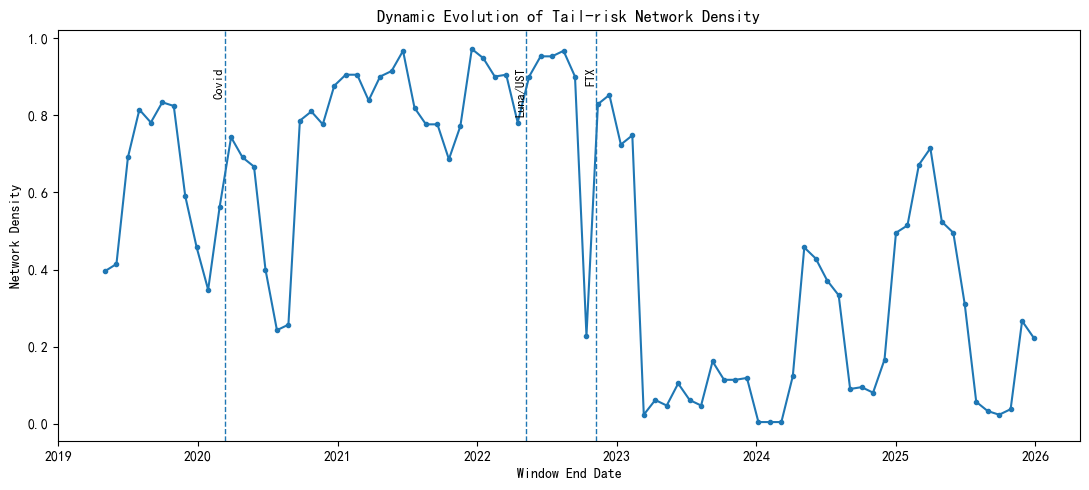

In [52]:
plot_dynamic_metric(
    dynamic_metrics,
    metric="density",
    ylabel="Network Density",
    title="Dynamic Evolution of Tail-risk Network Density",
    filename="figure_4_4_dynamic_density.png"
)

平均边权动态图——危机前后传染强度是否增强。

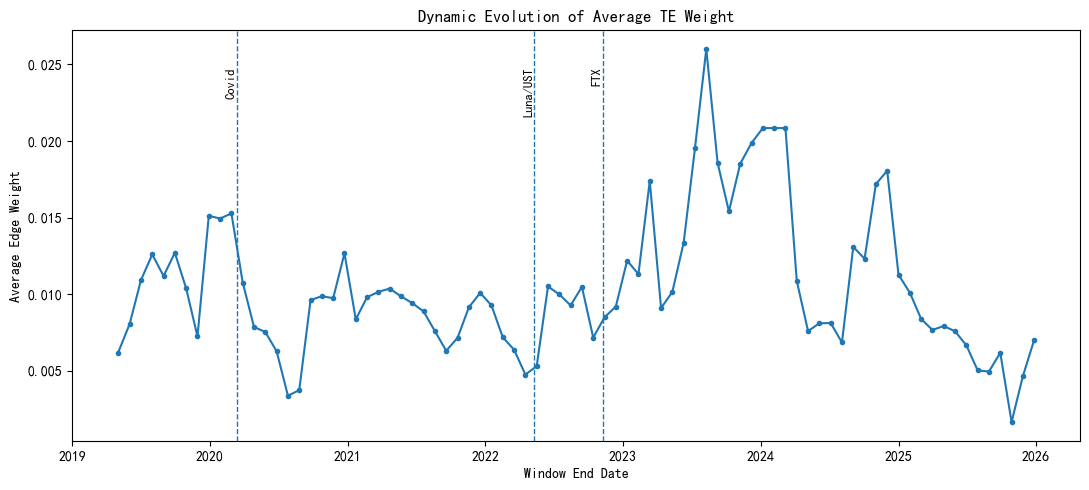

In [54]:
plot_dynamic_metric(
    dynamic_metrics,
    metric="avg_weight",
    ylabel="Average Edge Weight",
    title="Dynamic Evolution of Average TE Weight",
    filename="figure_4_5_dynamic_avg_weight.png"
)

网络熵动态图——熵下降意味着风险边权更集中，风险传染路径更依赖少数边。

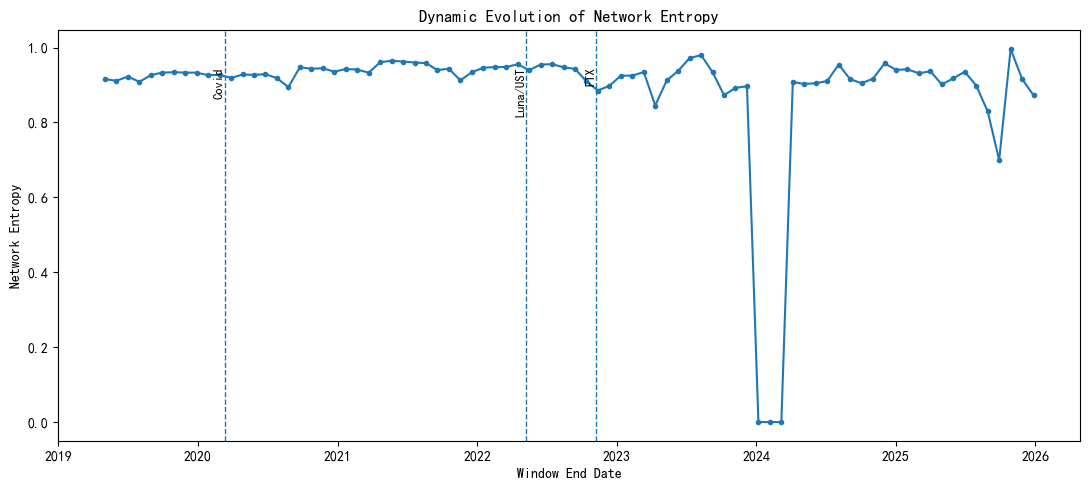

In [55]:
plot_dynamic_metric(
    dynamic_metrics,
    metric="network_entropy",
    ylabel="Network Entropy",
    title="Dynamic Evolution of Network Entropy",
    filename="figure_4_6_dynamic_entropy.png"
)

最大连通分量比例动态图——比例上升说明风险网络从局部连接变成更广泛连接。

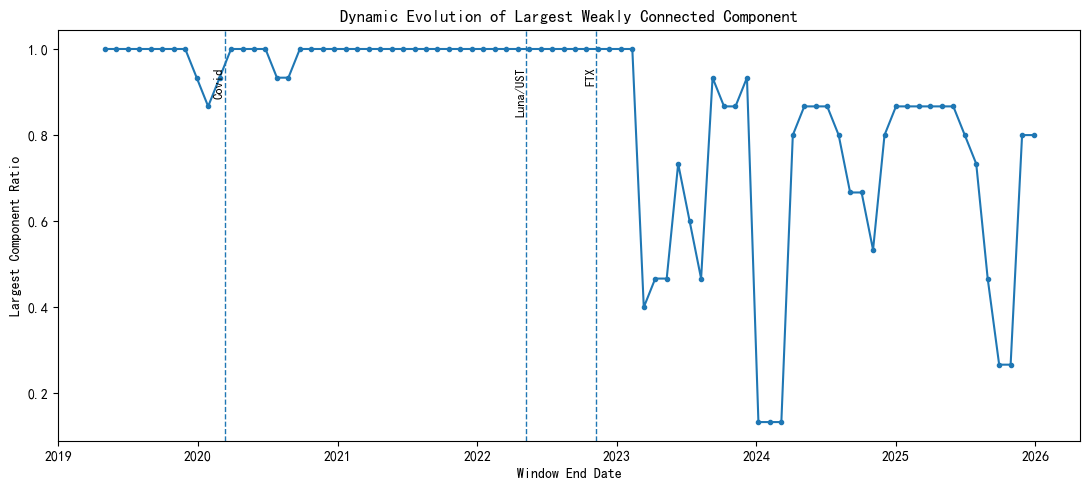

In [56]:
plot_dynamic_metric(
    dynamic_metrics,
    metric="max_component_ratio",
    ylabel="Largest Component Ratio",
    title="Dynamic Evolution of Largest Weakly Connected Component",
    filename="figure_4_7_dynamic_largest_component.png"
)

模块度动态图——模块度下降说明社区边界弱化，跨类别传染增强。

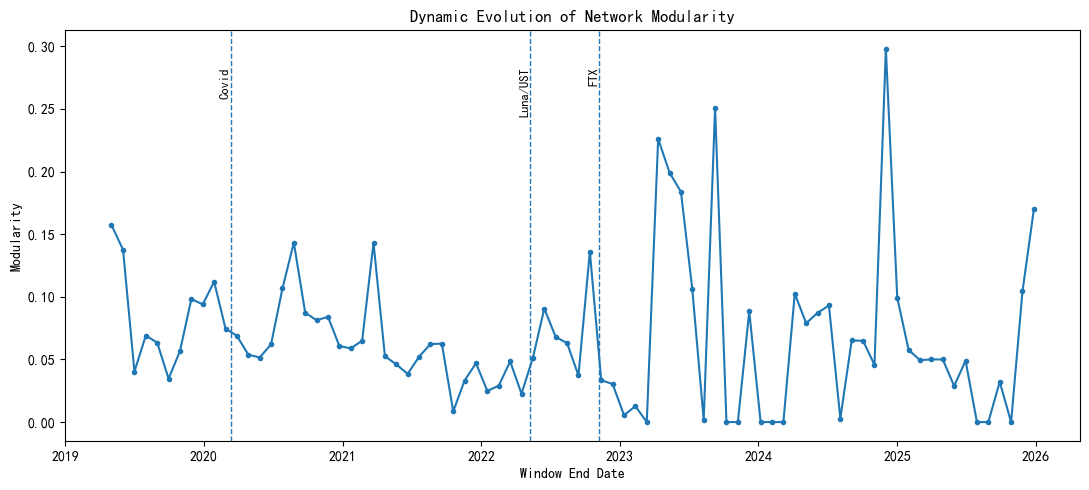

In [57]:
plot_dynamic_metric(
    dynamic_metrics,
    metric="modularity",
    ylabel="Modularity",
    title="Dynamic Evolution of Network Modularity",
    filename="figure_4_8_dynamic_modularity.png"
)

输出事件附近的指标

作表：表4-3 典型事件窗口下的尾部风险网络指标

In [58]:
def get_nearest_window(df, event_date):
    idx = (df["window_end"] - event_date).abs().idxmin()
    return df.loc[idx]

event_summary = []

for label, date in event_dates.items():
    row = get_nearest_window(dynamic_metrics, date)
    row_dict = row.to_dict()
    row_dict["event"] = label
    row_dict["event_date"] = date
    event_summary.append(row_dict)

event_summary_df = pd.DataFrame(event_summary)

event_summary_df = event_summary_df[
    [
        "event",
        "event_date",
        "window_start",
        "window_end",
        "edge_num",
        "density",
        "avg_weight",
        "network_entropy",
        "max_component_ratio",
        "modularity",
        "n_communities"
    ]
]

event_summary_df.to_csv(
    "processed_data/event_window_network_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

print(event_summary_df)

      event event_date window_start window_end  edge_num   density  \
0     Covid 2020-03-12   2019-10-31 2020-02-27       118  0.561905   
1  Luna/UST 2022-05-09   2022-01-18 2022-05-17       189  0.900000   
2       FTX 2022-11-08   2022-07-17 2022-11-13       174  0.828571   

   avg_weight  network_entropy  max_component_ratio  modularity  n_communities  
0    0.015270         0.927083             0.933333    0.074626              4  
1    0.005304         0.939725             1.000000    0.051386              3  
2    0.008492         0.885370             1.000000    0.033387              2  


输出危机前后均值对比——“危机前后是否发生变化”。

定义事件前后两个窗口：

事件前：事件日前180天内的滚动窗口；
事件后：事件日后180天内的滚动窗口。

In [59]:
def compare_pre_post_event(df, event_date, days=180):
    pre_mask = (df["window_end"] >= event_date - pd.Timedelta(days=days)) & (df["window_end"] < event_date)
    post_mask = (df["window_end"] >= event_date) & (df["window_end"] <= event_date + pd.Timedelta(days=days))

    metrics_cols = [
        "edge_num",
        "density",
        "avg_weight",
        "network_entropy",
        "max_component_ratio",
        "modularity"
    ]

    pre_mean = df.loc[pre_mask, metrics_cols].mean()
    post_mean = df.loc[post_mask, metrics_cols].mean()

    comparison = pd.DataFrame({
        "pre_event_mean": pre_mean,
        "post_event_mean": post_mean,
        "change": post_mean - pre_mean
    })

    return comparison


all_event_comparisons = []

for label, date in event_dates.items():
    comp = compare_pre_post_event(dynamic_metrics, date, days=180)
    comp["event"] = label
    all_event_comparisons.append(comp.reset_index().rename(columns={"index": "metric"}))

event_comparison_df = pd.concat(all_event_comparisons, ignore_index=True)

event_comparison_df.to_csv(
    "processed_data/event_pre_post_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

print(event_comparison_df)

                 metric  pre_event_mean  post_event_mean     change     event
0              edge_num      126.500000       105.000000 -21.500000     Covid
1               density        0.602381         0.500000  -0.102381     Covid
2            avg_weight        0.012607         0.006591  -0.006016     Covid
3       network_entropy        0.931198         0.919313  -0.011884     Covid
4   max_component_ratio        0.955556         0.977778   0.022222     Covid
5            modularity        0.078369         0.081017   0.002648     Covid
6              edge_num      184.666667       171.500000 -13.166667  Luna/UST
7               density        0.879365         0.816667  -0.062698  Luna/UST
8            avg_weight        0.007805         0.008786   0.000981  Luna/UST
9       network_entropy        0.940734         0.941716   0.000982  Luna/UST
10  max_component_ratio        1.000000         1.000000   0.000000  Luna/UST
11           modularity        0.034169         0.074386   0.040

### 4.4代码部分

1.写社区识别函数

In [60]:
def detect_communities(G):
    """
    输入有向加权网络 G。
    输出：
    1. communities: 社区列表
    2. node_community: 每个节点对应的社区编号
    3. modularity_value: 模块度
    """
    H = directed_to_undirected_weighted(G)

    if H.number_of_edges() == 0:
        node_community = {node: np.nan for node in H.nodes()}
        return [], node_community, np.nan

    communities = list(greedy_modularity_communities(H, weight="weight"))

    node_community = {}
    for idx, comm in enumerate(communities, start=1):
        for node in comm:
            node_community[node] = idx

    modularity_value = modularity(H, communities, weight="weight")

    return communities, node_community, modularity_value

2.对全样本网络做社区识别

In [61]:
communities_full, node_community_full, modularity_full = detect_communities(G)

print("全样本社区数量：", len(communities_full))
print("全样本模块度：", modularity_full)

for idx, comm in enumerate(communities_full, start=1):
    print(f"社区{idx}：", sorted(list(comm)))

全样本社区数量： 5
全样本模块度： 0.17324311371067236
社区1： ['cro', 'link', 'trx', 'usdt', 'xmr']
社区2： ['ada', 'btc', 'eth', 'usdc']
社区3： ['bch', 'ltc', 'xlm', 'xrp']
社区4： ['doge']
社区5： ['zec']


3.成表

In [63]:
#表4-4 全样本尾部风险传染网络社区划分
community_table_full = pd.DataFrame({
    "coin": coins,
    "asset_group": [asset_group.get(c, "") for c in coins],
    "community": [node_community_full.get(c, np.nan) for c in coins]
})

community_table_full = community_table_full.sort_values(["community", "coin"])

community_table_full.to_csv(
    "processed_data/table_4_4_full_sample_communities.csv",
    index=False,
    encoding="utf-8-sig"
)

print(community_table_full)

    coin  asset_group  community
3    cro  平台生态及情绪交易资产          1
6   link    公链及基础设施资产          1
8    trx    公链及基础设施资产          1
10  usdt          稳定币          1
12   xmr    支付结算及隐私资产          1
0    ada    公链及基础设施资产          2
2    btc       核心定价资产          2
5    eth       核心定价资产          2
9   usdc          稳定币          2
1    bch    支付结算及隐私资产          3
7    ltc    支付结算及隐私资产          3
11   xlm    支付结算及隐私资产          3
13   xrp    支付结算及隐私资产          3
4   doge  平台生态及情绪交易资产          4
14   zec    支付结算及隐私资产          5


4：画全样本社区结构图

这一张图和全样本网络图不同：
前面节点颜色是资产类别；这里节点颜色是算法识别出来的社区。

C:\Users\liulian\AppData\Local\Temp\ipykernel_37512\2993663311.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", len(communities))


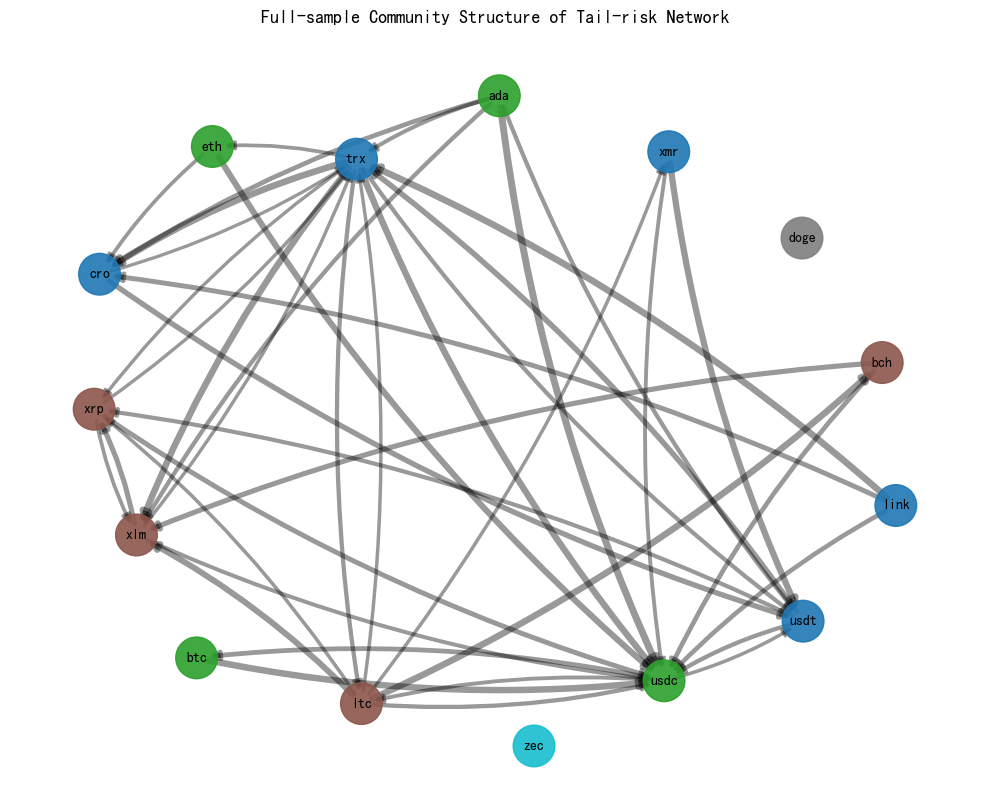

In [65]:
def plot_community_network(G, node_community, title, filename):
    """
    画社区网络图。
    节点颜色按照社区编号区分。
    """
    plt.figure(figsize=(10, 8))

    pos = nx.spring_layout(G, seed=42, k=0.9)

    communities = sorted(set([v for v in node_community.values() if not pd.isna(v)]))
    color_map = plt.cm.get_cmap("tab10", len(communities))

    node_colors = []
    for node in G.nodes():
        comm_id = node_community.get(node, np.nan)
        if pd.isna(comm_id):
            node_colors.append("#cccccc")
        else:
            node_colors.append(color_map(int(comm_id) - 1))

    edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
    max_w = max(edge_weights) if len(edge_weights) > 0 else 1
    edge_widths = [1 + 4 * w / max_w for w in edge_weights]

    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=node_colors,
        node_size=900,
        alpha=0.9
    )

    nx.draw_networkx_edges(
        G,
        pos,
        width=edge_widths,
        alpha=0.4,
        arrows=True,
        arrowsize=12,
        connectionstyle="arc3,rad=0.08"
    )

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=10,
        font_weight="bold"
    )

    plt.title(title, fontsize=13)
    plt.axis("off")
    plt.tight_layout()

    plt.savefig(
        f"processed_data/{filename}",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


plot_community_network(
    G,
    node_community_full,
    title="Full-sample Community Structure of Tail-risk Network",
    filename="figure_4_9_full_sample_community_network.png"
)

5.从滚动窗口中找到事件附近窗口

In [66]:
print(list(adj_matrices_by_window.keys())[:5])
print(list(adj_matrices_by_window.keys())[-5:])

['2019-05-02', '2019-06-02', '2019-07-02', '2019-08-01', '2019-08-31']
['2025-08-29', '2025-09-28', '2025-10-28', '2025-11-27', '2025-12-27']


In [67]:
def find_nearest_window_key(adj_dict, event_date):
    """
    从 adj_matrices_by_window 的 key 中找到离事件日期最近的窗口。
    key 格式一般是 'YYYY-MM-DD'
    """
    keys = list(adj_dict.keys())
    dates = pd.to_datetime(keys)

    idx = np.argmin(np.abs(dates - event_date))
    nearest_key = keys[idx]
    nearest_date = dates[idx]

    return nearest_key, nearest_date

In [69]:
#确认4.3 4.4事件窗口一致
event_dates = {
    "Covid": pd.Timestamp("2020-03-12"),
    "Luna/UST": pd.Timestamp("2022-05-09"),
    "FTX": pd.Timestamp("2022-11-08")
}

for event_name, event_date in event_dates.items():
    key, nearest_date = find_nearest_window_key(adj_matrices_by_window, event_date)
    print(event_name, "事件日期：", event_date.date(), "最近窗口：", key)

Covid 事件日期： 2020-03-12 最近窗口： 2020-02-27
Luna/UST 事件日期： 2022-05-09 最近窗口： 2022-05-17
FTX 事件日期： 2022-11-08 最近窗口： 2022-11-13


6：把某个窗口的邻接矩阵转成网络

In [70]:
def build_graph_from_adj_matrix(adj_matrix, coins, asset_group):
    """
    根据已经筛选后的邻接矩阵构建有向加权网络。
    """
    G_event = nx.DiGraph()

    for coin in coins:
        G_event.add_node(coin, group=asset_group.get(coin, ""))

    for i in coins:
        for j in coins:
            if i != j:
                weight = adj_matrix.loc[i, j]
                if weight > 0:
                    G_event.add_edge(i, j, weight=weight)

    return G_event

7：对三个事件窗口做社区识别

In [71]:
event_community_results = []
event_graphs = {}
event_node_communities = {}

for event_name, event_date in event_dates.items():
    key, nearest_date = find_nearest_window_key(adj_matrices_by_window, event_date)

    adj_event = adj_matrices_by_window[key]
    G_event = build_graph_from_adj_matrix(adj_event, coins, asset_group)

    communities_event, node_community_event, modularity_event = detect_communities(G_event)

    event_graphs[event_name] = G_event
    event_node_communities[event_name] = node_community_event

    event_community_results.append({
        "event": event_name,
        "event_date": event_date,
        "window_end": nearest_date,
        "edge_num": G_event.number_of_edges(),
        "density": nx.density(G_event),
        "n_communities": len(communities_event),
        "modularity": modularity_event
    })

    print("\n", event_name)
    print("事件日期：", event_date.date())
    print("最近窗口：", key)
    print("边数：", G_event.number_of_edges())
    print("密度：", nx.density(G_event))
    print("社区数：", len(communities_event))
    print("模块度：", modularity_event)

    for idx, comm in enumerate(communities_event, start=1):
        print(f"社区{idx}：", sorted(list(comm)))


 Covid
事件日期： 2020-03-12
最近窗口： 2020-02-27
边数： 118
密度： 0.5619047619047619
社区数： 4
模块度： 0.07462591537739018
社区1： ['bch', 'eth', 'trx', 'xlm', 'xrp', 'zec']
社区2： ['ada', 'btc', 'cro', 'link', 'usdc']
社区3： ['ltc', 'usdt', 'xmr']
社区4： ['doge']

 Luna/UST
事件日期： 2022-05-09
最近窗口： 2022-05-17
边数： 189
密度： 0.9
社区数： 3
模块度： 0.05138612946221954
社区1： ['btc', 'doge', 'eth', 'link', 'ltc', 'trx', 'xmr']
社区2： ['ada', 'cro', 'usdt', 'xrp']
社区3： ['bch', 'usdc', 'xlm', 'zec']

 FTX
事件日期： 2022-11-08
最近窗口： 2022-11-13
边数： 174
密度： 0.8285714285714286
社区数： 2
模块度： 0.03338706411687001
社区1： ['ada', 'bch', 'doge', 'eth', 'ltc', 'trx', 'usdc', 'xlm', 'xmr', 'xrp']
社区2： ['btc', 'cro', 'link', 'usdt', 'zec']


8：整理事件窗口社区结构对比表

表4-5 典型事件窗口尾部风险网络社区结构对比

In [72]:
event_community_summary = pd.DataFrame(event_community_results)

event_community_summary.to_csv(
    "processed_data/table_4_5_event_community_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print(event_community_summary)

      event event_date window_end  edge_num   density  n_communities  \
0     Covid 2020-03-12 2020-02-27       118  0.561905              4   
1  Luna/UST 2022-05-09 2022-05-17       189  0.900000              3   
2       FTX 2022-11-08 2022-11-13       174  0.828571              2   

   modularity  
0    0.074626  
1    0.051386  
2    0.033387  


9.整理每个事件的节点社区归属表

In [73]:
event_node_table_list = []

for event_name, node_comm in event_node_communities.items():
    for coin in coins:
        event_node_table_list.append({
            "event": event_name,
            "coin": coin,
            "asset_group": asset_group.get(coin, ""),
            "community": node_comm.get(coin, np.nan)
        })

event_node_community_table = pd.DataFrame(event_node_table_list)

event_node_community_table.to_csv(
    "processed_data/table_4_6_event_node_communities.csv",
    index=False,
    encoding="utf-8-sig"
)

print(event_node_community_table.head(30))

       event  coin  asset_group  community
0      Covid   ada    公链及基础设施资产          2
1      Covid   bch    支付结算及隐私资产          1
2      Covid   btc       核心定价资产          2
3      Covid   cro  平台生态及情绪交易资产          2
4      Covid  doge  平台生态及情绪交易资产          4
5      Covid   eth       核心定价资产          1
6      Covid  link    公链及基础设施资产          2
7      Covid   ltc    支付结算及隐私资产          3
8      Covid   trx    公链及基础设施资产          1
9      Covid  usdc          稳定币          2
10     Covid  usdt          稳定币          3
11     Covid   xlm    支付结算及隐私资产          1
12     Covid   xmr    支付结算及隐私资产          3
13     Covid   xrp    支付结算及隐私资产          1
14     Covid   zec    支付结算及隐私资产          1
15  Luna/UST   ada    公链及基础设施资产          2
16  Luna/UST   bch    支付结算及隐私资产          3
17  Luna/UST   btc       核心定价资产          1
18  Luna/UST   cro  平台生态及情绪交易资产          2
19  Luna/UST  doge  平台生态及情绪交易资产          1
20  Luna/UST   eth       核心定价资产          1
21  Luna/UST  link    公链及基础设施资产          1
22  Luna/US

10 画三个事件窗口的社区网络图

C:\Users\liulian\AppData\Local\Temp\ipykernel_37512\2993663311.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", len(communities))


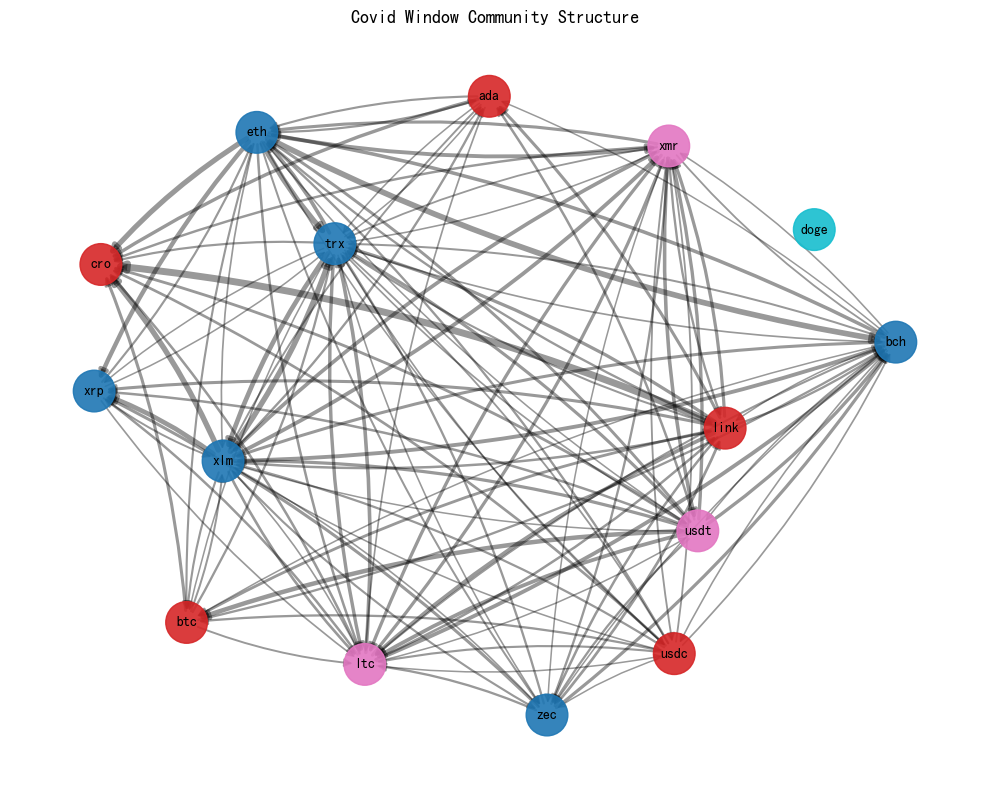

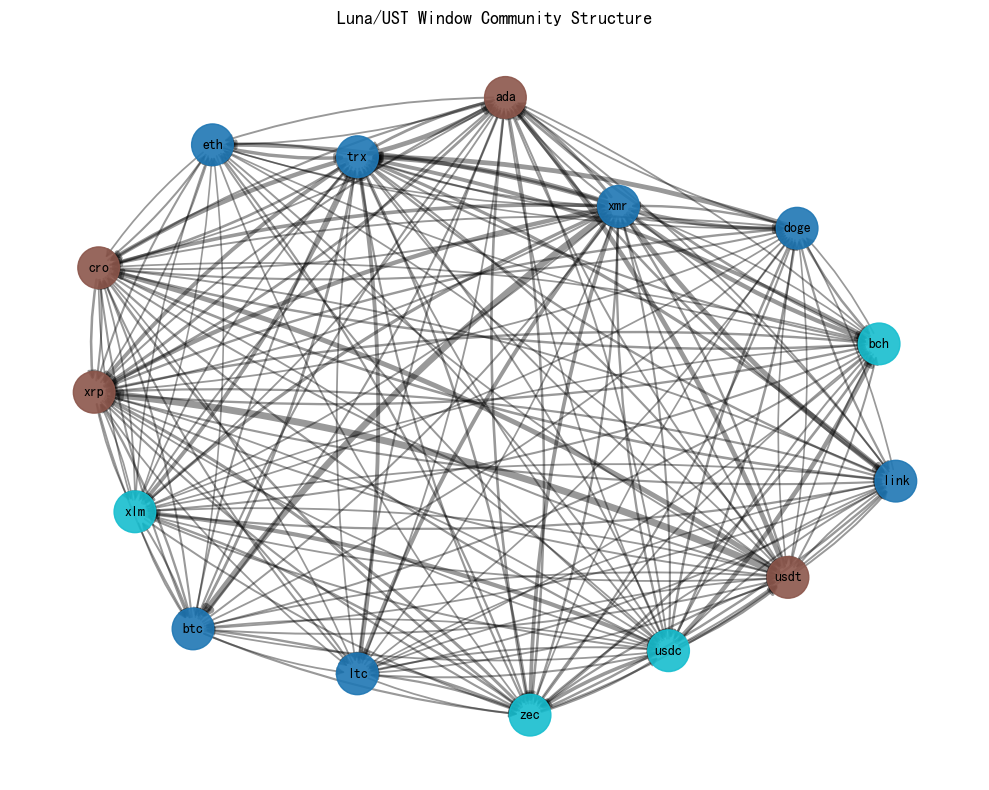

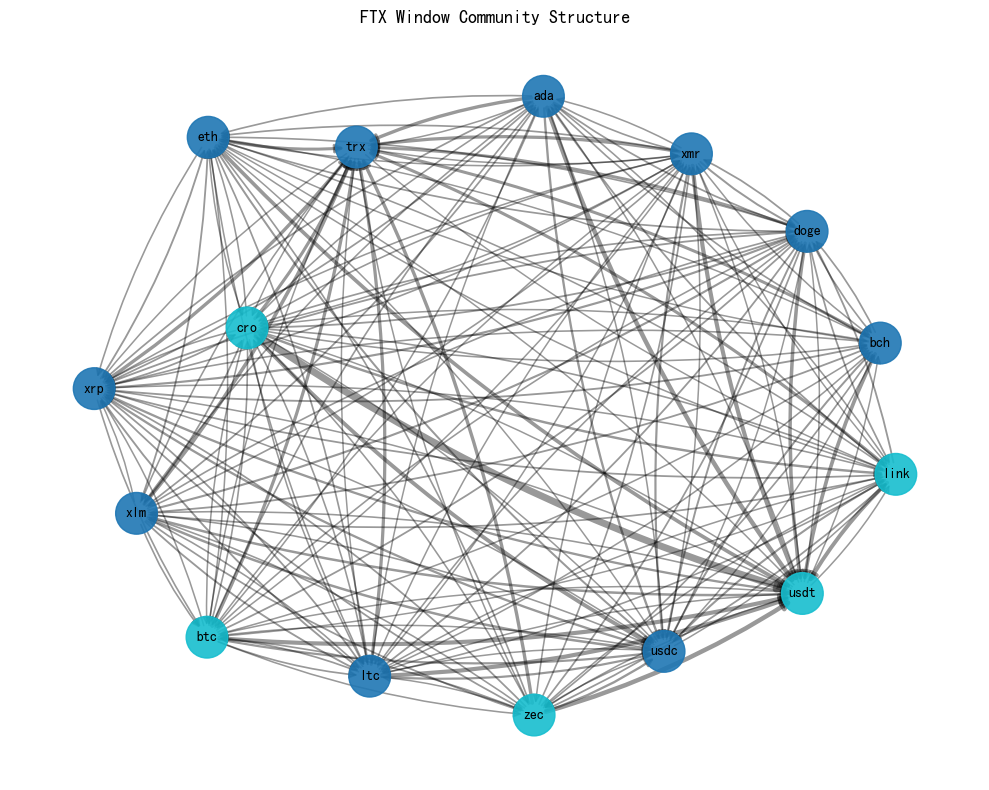

In [74]:
for event_name in event_dates.keys():
    G_event = event_graphs[event_name]
    node_comm = event_node_communities[event_name]

    plot_community_network(
        G_event,
        node_comm,
        title=f"{event_name} Window Community Structure",
        filename=f"figure_4_10_{event_name.replace('/', '_')}_community_network.png"
    )

11：把全样本社区和资产分类做对照

In [75]:
community_group_crosstab = pd.crosstab(
    community_table_full["community"],
    community_table_full["asset_group"]
)

community_group_crosstab.to_csv(
    "processed_data/table_4_7_community_asset_group_crosstab.csv",
    encoding="utf-8-sig"
)

print(community_group_crosstab)

asset_group  公链及基础设施资产  平台生态及情绪交易资产  支付结算及隐私资产  核心定价资产  稳定币
community                                                  
1                    2            1          1       0    1
2                    1            0          0       2    1
3                    0            0          4       0    0
4                    0            1          0       0    0
5                    0            0          1       0    0


In [76]:
#全样本社区汇总表
community_summary_full = (
    community_table_full
    .groupby("community")
    .agg(
        包含币种=("coin", lambda x: "、".join([c.upper() for c in x])),
        资产类别=("asset_group", lambda x: "；".join(sorted(set(x))))
    )
    .reset_index()
    .rename(columns={"community": "社区编号"})
)

community_summary_full.to_csv(
    "processed_data/table_4_8_full_sample_community_summary_cn.csv",
    index=False,
    encoding="utf-8-sig"
)

print(community_summary_full)

   社区编号                   包含币种                                 资产类别
0     1  CRO、LINK、TRX、USDT、XMR  公链及基础设施资产；平台生态及情绪交易资产；支付结算及隐私资产；稳定币
1     2       ADA、BTC、ETH、USDC                 公链及基础设施资产；核心定价资产；稳定币
2     3        BCH、LTC、XLM、XRP                            支付结算及隐私资产
3     4                   DOGE                          平台生态及情绪交易资产
4     5                    ZEC                            支付结算及隐私资产


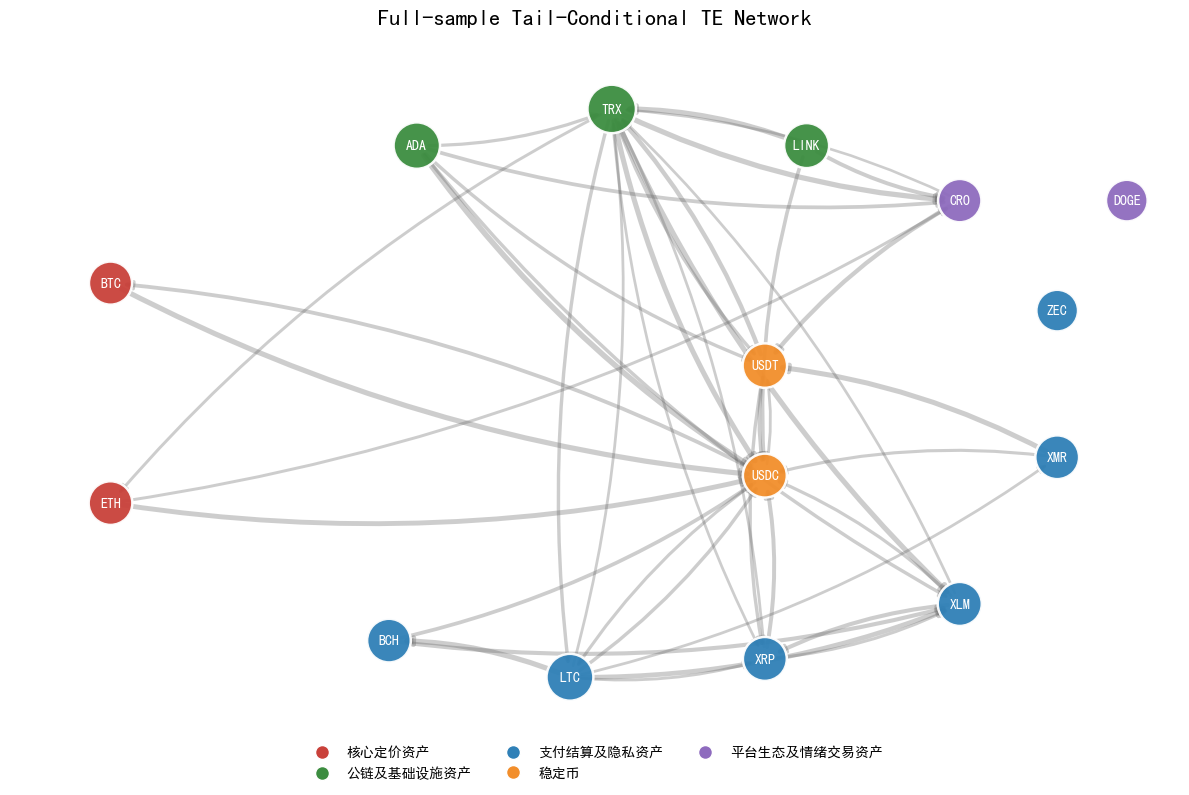

In [108]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# 重新设置颜色，适合PPT
group_color = {
    "核心定价资产": "#C9413A",          # 红
    "公链及基础设施资产": "#3C8D40",    # 绿
    "支付结算及隐私资产": "#2F80B7",    # 蓝
    "稳定币": "#F28E2B",              # 橙
    "平台生态及情绪交易资产": "#8E6BBE" # 紫
}

node_colors = [
    group_color.get(G.nodes[node]["group"], "#999999")
    for node in G.nodes()
]

# 手动布局：按资产类别分区
pos = {
    # 核心定价资产：左侧
    "btc": (-1.8, 0.6),
    "eth": (-1.8, -0.6),

    # 公链及基础设施资产：上方
    "ada": (-0.7, 1.35),
    "trx": (0.0, 1.55),
    "link": (0.7, 1.35),

    # 稳定币：中心偏右
    "usdt": (0.55, 0.15),
    "usdc": (0.55, -0.45),

    # 支付结算及隐私资产：下方和右侧
    "bch": (-0.8, -1.35),
    "ltc": (-0.15, -1.55),
    "xrp": (0.55, -1.45),
    "xlm": (1.25, -1.15),
    "xmr": (1.6, -0.35),
    "zec": (1.6, 0.45),

    # 平台生态及情绪交易资产：右上
    "cro": (1.25, 1.05),
    "doge": (1.85, 1.05)
}

# 节点大小：按出度强度，但不要太夸张
node_sizes = [
    900 + 18000 * out_strength.get(node, 0)
    for node in G.nodes()
]

# 边宽：按TE权重
edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
max_w = max(edge_weights) if len(edge_weights) > 0 else 1
edge_widths = [0.8 + 3.2 * w / max_w for w in edge_weights]

plt.figure(figsize=(12, 8))

# 先画边
nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    edge_color="#666666",
    alpha=0.32,
    arrows=True,
    arrowsize=12,
    arrowstyle="-|>",
    connectionstyle="arc3,rad=0.10"
)

# 再画节点
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors="white",
    linewidths=1.8,
    alpha=0.95
)

# 节点标签大写
labels = {node: node.upper() for node in G.nodes()}
nx.draw_networkx_labels(
    G,
    pos,
    labels=labels,
    font_size=10,
    font_weight="bold",
    font_color="white"
)

# 添加图例
legend_items = []
for group, color in group_color.items():
    legend_items.append(
        plt.Line2D(
            [0], [0],
            marker="o",
            color="w",
            label=group,
            markerfacecolor=color,
            markersize=10
        )
    )

plt.legend(
    handles=legend_items,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    frameon=False,
    fontsize=10
)

plt.title(
    "Full-sample Tail-Conditional TE Network",
    fontsize=16,
    fontweight="bold",
    pad=18
)

plt.axis("off")
plt.tight_layout()

plt.savefig(
    "processed_data/figure_4_1_full_sample_te_network_ppt.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

In [111]:
import networkx as nx
import pandas as pd
import numpy as np

# 读取前20%强边邻接矩阵
adj_matrix = pd.read_csv("processed_data/te_adj_top20_full_sample.csv", index_col=0)

G = nx.DiGraph()

# 添加节点
for coin in adj_matrix.index:
    G.add_node(coin)

# 添加边
for i in adj_matrix.index:
    for j in adj_matrix.columns:
        weight = adj_matrix.loc[i, j]
        if i != j and weight > 0:
            G.add_edge(i, j, weight=weight)

# 注意：NetworkX的介数中心性把权重理解为“距离”
# TE越大表示关系越强，所以要转成 distance = 1 / weight
for u, v, d in G.edges(data=True):
    d["distance"] = 1 / d["weight"]

betweenness = nx.betweenness_centrality(
    G,
    weight="distance",
    normalized=True
)

# 加回 node_stats
node_stats["betweenness"] = node_stats["coin"].map(betweenness)

print(node_stats[[
    "coin", "out_strength", "in_strength", "net_out_strength", "betweenness"
]].sort_values("betweenness", ascending=False))

    coin  out_strength  in_strength  net_out_strength  betweenness
9   usdc      0.005636     0.029001         -0.023364     0.225275
8    trx      0.017730     0.014007          0.003723     0.192308
10  usdt      0.006920     0.011726         -0.004806     0.142857
7    ltc      0.013265     0.003761          0.009504     0.137363
11   xlm      0.005858     0.013059         -0.007201     0.038462
3    cro      0.004129     0.010062         -0.005933     0.005495
12   xmr      0.005169     0.001469          0.003700     0.005495
0    ada      0.012104     0.000000          0.012104     0.000000
1    bch      0.004942     0.003587          0.001354     0.000000
2    btc      0.003572     0.002386          0.001187     0.000000
4   doge      0.000000     0.000000          0.000000     0.000000
5    eth      0.004952     0.001619          0.003332     0.000000
6   link      0.008358     0.000000          0.008358     0.000000
13   xrp      0.005563     0.007521         -0.001957     0.00

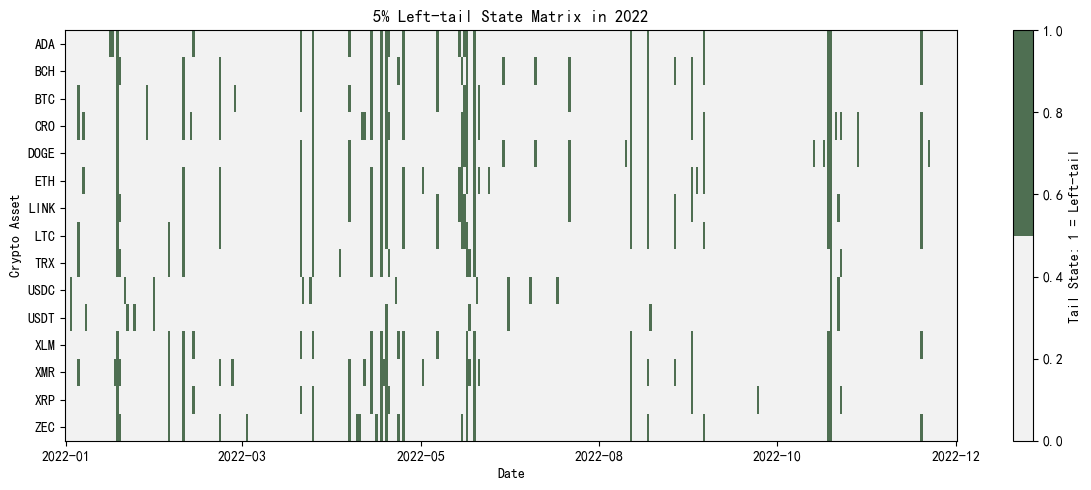

In [119]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 如果 tail_state 的 index 是日期，columns 是币种
tail_plot = tail_state.copy()

# 只截取一个代表性时间段，避免全样本太密
# 可以选 2022年，包含 Luna/UST 和 FTX
tail_plot_period = tail_plot.loc["2022-01-01":"2022-12-31"]

plt.figure(figsize=(12, 5))

plt.imshow(
    tail_plot_period.T,
    aspect="auto",
    interpolation="nearest",
    cmap = ListedColormap(["#F2F2F2", "#4F6F52"])
)

plt.yticks(
    range(len(tail_plot_period.columns)),
    [c.upper() for c in tail_plot_period.columns]
)

# 横轴日期不要太密
date_ticks = np.linspace(0, len(tail_plot_period.index)-1, 6, dtype=int)
plt.xticks(
    date_ticks,
    [tail_plot_period.index[i].strftime("%Y-%m") for i in date_ticks],
    rotation=0
)

plt.xlabel("Date")
plt.ylabel("Crypto Asset")
plt.title("5% Left-tail State Matrix in 2022")

plt.colorbar(label="Tail State: 1 = Left-tail")
plt.tight_layout()

plt.savefig(
    "processed_data/figure_tail_state_matrix_2022.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [120]:
#前20%边
import pandas as pd
import numpy as np
import os

adj_matrix = pd.read_csv(
    "processed_data/te_adj_top20_full_sample.csv",
    index_col=0
)

print(adj_matrix.shape)
print(adj_matrix.head())

(15, 15)
      ada  bch  btc       cro  doge  eth  link  ltc       trx      usdc  \
ada   0.0  0.0  0.0  0.002316   0.0  0.0   0.0  0.0  0.001839  0.003891   
bch   0.0  0.0  0.0  0.000000   0.0  0.0   0.0  0.0  0.000000  0.002311   
btc   0.0  0.0  0.0  0.000000   0.0  0.0   0.0  0.0  0.000000  0.003572   
cro   0.0  0.0  0.0  0.000000   0.0  0.0   0.0  0.0  0.001342  0.000000   
doge  0.0  0.0  0.0  0.000000   0.0  0.0   0.0  0.0  0.000000  0.000000   

          usdt       xlm  xmr  xrp  zec  
ada   0.002012  0.002047  0.0  0.0  0.0  
bch   0.000000  0.002630  0.0  0.0  0.0  
btc   0.000000  0.000000  0.0  0.0  0.0  
cro   0.002787  0.000000  0.0  0.0  0.0  
doge  0.000000  0.000000  0.0  0.0  0.0  


In [121]:
edge_list = []

for source in adj_matrix.index:
    for target in adj_matrix.columns:
        weight = adj_matrix.loc[source, target]
        if source != target and weight > 0:
            edge_list.append({
                "Source": source,
                "Target": target,
                "Type": "Directed",
                "Weight": weight
            })

edges_gephi = pd.DataFrame(edge_list)

edges_gephi = edges_gephi.sort_values(
    "Weight",
    ascending=False
).reset_index(drop=True)

print(edges_gephi.head(10))
print("边数：", len(edges_gephi))

  Source Target      Type    Weight
0    ada   usdc  Directed  0.003891
1   link    trx  Directed  0.003631
2    trx    cro  Directed  0.003623
3    ltc    bch  Directed  0.003587
4    btc   usdc  Directed  0.003572
5    trx    xlm  Directed  0.003551
6    trx   usdc  Directed  0.003507
7    xmr   usdt  Directed  0.003425
8    eth   usdc  Directed  0.003314
9    ltc    xlm  Directed  0.003191
边数： 42


In [130]:
import pandas as pd
import matplotlib.pyplot as plt

dynamic_metrics = pd.read_csv("processed_data/dynamic_network_metrics.csv")

print(dynamic_metrics.head())
print(dynamic_metrics.columns)

                window_start                 window_end  edge_num   density  \
0  2019-01-03 00:00:00+00:00  2019-05-02 00:00:00+00:00        83  0.395238   
1  2019-02-02 00:00:00+00:00  2019-06-02 00:00:00+00:00        87  0.414286   
2  2019-03-04 00:00:00+00:00  2019-07-02 00:00:00+00:00       145  0.690476   
3  2019-04-03 00:00:00+00:00  2019-08-01 00:00:00+00:00       171  0.814286   
4  2019-05-03 00:00:00+00:00  2019-08-31 00:00:00+00:00       164  0.780952   

   avg_weight  total_weight  network_entropy  max_component_ratio  modularity  \
0    0.006165      0.511660         0.915879                  1.0    0.157634   
1    0.008058      0.701073         0.911439                  1.0    0.137593   
2    0.010918      1.583038         0.922509                  1.0    0.040320   
3    0.012596      2.153862         0.908596                  1.0    0.069058   
4    0.011186      1.834507         0.926404                  1.0    0.063395   

   n_communities  
0              4  


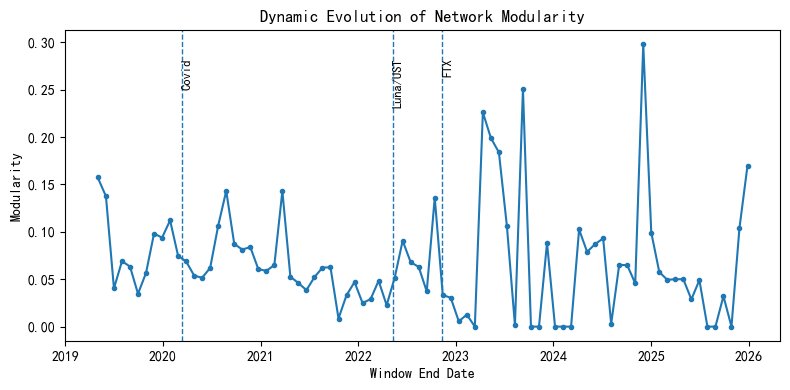

In [131]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取动态网络指标
dynamic_metrics = pd.read_csv("processed_data/dynamic_network_metrics.csv")

# 日期格式转换
dynamic_metrics["window_end"] = pd.to_datetime(dynamic_metrics["window_end"])

plt.figure(figsize=(8, 4))

plt.plot(
    dynamic_metrics["window_end"],
    dynamic_metrics["modularity"],
    marker="o",
    linewidth=1.5,
    markersize=3
)

# 标注三类事件
event_dates = {
    "Covid": "2020-03-12",
    "Luna/UST": "2022-05-09",
    "FTX": "2022-11-11"
}

ymax = dynamic_metrics["modularity"].max()

for event, date in event_dates.items():
    event_date = pd.to_datetime(date)
    plt.axvline(event_date, linestyle="--", linewidth=1)
    plt.text(
        event_date,
        ymax * 0.95,
        event,
        rotation=90,
        va="top",
        fontsize=9
    )

plt.title("Dynamic Evolution of Network Modularity")
plt.xlabel("Window End Date")
plt.ylabel("Modularity")
plt.tight_layout()

plt.savefig(
    "processed_data/figure_dynamic_modularity_for_ppt.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()